# Random Forest on IDX30 Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, glob, os, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder


In [2]:
BASE_DIR      = 'CS-IDX30 version 3'
FUND_DIR      = os.path.join(BASE_DIR, 'financial report data', '1')
PRICE_DIR     = os.path.join(BASE_DIR, 'pricehistory data')

TARGET_TICKER  = 'BBCA'       # stock we ultimately predict for the hybrid
TEST_QUARTERS  = 2            # last N quarters per stock held out
N_ESTIMATORS   = 200
RANDOM_STATE   = 42

RF_PREDICTIONS_OUT = 'rf_idx30_predictions.csv'
RF_MODEL_OUT       = 'rf_idx30_model.pkl'


In [3]:
# Map ticker → price file path
price_lookup = {}
for path in glob.glob(os.path.join(PRICE_DIR, '**', '*.xlsx'), recursive=True):
    ticker = os.path.basename(path).replace('.JK_dataprice.xlsx', '')
    price_lookup[ticker] = path

# Map ticker → sector (derived from subfolder name)
sector_lookup = {}
for path in glob.glob(os.path.join(PRICE_DIR, '**', '*.xlsx'), recursive=True):
    ticker = os.path.basename(path).replace('.JK_dataprice.xlsx', '')
    sector = os.path.basename(os.path.dirname(path))
    sector_lookup[ticker] = sector

print(f"Found {len(price_lookup)} price files")
for ticker, sector in sorted(sector_lookup.items()):
    print(f"  {ticker:<8} → {sector}")


Found 30 price files
  ADRO     → Energy and Utils
  ANTM     → Mines and Basic Materials
  ASII     → Otomotive and Industrials
  BBCA     → Finance
  BBNI     → Finance
  BBRI     → Finance
  BBTN     → Finance
  BMRI     → Finance
  BRPT     → Mines and Basic Materials
  BUKA     → Tech
  CPIN     → Consumer Goods
  EMTK     → Tech
  EXCL     → Telecommunications
  GOTO     → Tech
  ICBP     → Consumer Goods
  INCO     → Mines and Basic Materials
  INDF     → Consumer Goods
  INKP     → Mines and Basic Materials
  KLBF     → Healthcare
  MDKA     → Mines and Basic Materials
  MIKA     → Healthcare
  PGAS     → Energy and Utils
  PTBA     → Energy and Utils
  SMGR     → Mines and Basic Materials
  TBIG     → Telecommunications
  TINS     → Mines and Basic Materials
  TLKM     → Telecommunications
  TOWR     → Telecommunications
  UNTR     → Mines and Basic Materials
  UNVR     → Consumer Goods


In [4]:
_QUARTER_END = {'Q1': (3,31), 'Q2': (6,30), 'Q3': (9,30), 'Q4': (12,31)}

def _parse_value(raw):
    raw = raw.replace(' B', '').replace(',', '').strip()
    if raw in ('-', '', 'N/A', '-'):
        return 0.0
    if raw.startswith('(') and raw.endswith(')'):
        return -float(raw[1:-1])
    return float(raw)


def parse_series(year_values, col):
    rows = []
    for yb in year_values:
        year = int(yb['year'])
        for p in yb['period_values']:
            m, d = _QUARTER_END[p['period']]
            rows.append({'ds': pd.Timestamp(year, m, d), col: _parse_value(p['quarter_value'])})
    return pd.DataFrame(rows).sort_values('ds').reset_index(drop=True)

def load_one_fundamental(path, ticker):
    with open(path) as f:
        data = json.load(f)
    groups = data['data']['financial_year_parent']['financial_year_groups']
    ni_years  = next(g['financial_year_values'] for g in groups if g['fitem_name'] == 'Net Income')
    rev_years = next(g['financial_year_values'] for g in groups if g['fitem_name'] == 'Revenue')
    fund = parse_series(ni_years, 'net_income').merge(parse_series(rev_years, 'revenue'), on='ds')
    fund['net_profit_margin'] = fund['net_income'] / fund['revenue'].replace(0, float('nan'))
    fund['ni_growth_qoq']     = fund['net_income'].pct_change().fillna(0)
    fund['rev_growth_qoq']    = fund['revenue'].pct_change().fillna(0)
    fund['ticker']            = ticker
    fund['sector']            = sector_lookup[ticker]
    return fund

all_fund = []
for fname in sorted(os.listdir(FUND_DIR)):
    if not fname.endswith('.json'):
        continue
    ticker = fname.replace('_fundamental.json', '')
    if ticker not in price_lookup:
        continue
    fund = load_one_fundamental(os.path.join(FUND_DIR, fname), ticker)
    all_fund.append(fund)

df_fund = pd.concat(all_fund, ignore_index=True)
le = LabelEncoder()
df_fund['sector_code'] = le.fit_transform(df_fund['sector'])

print(f"\n[Fundamentals]  {len(df_fund)} rows across {df_fund['ticker'].nunique()} stocks")
print(df_fund.groupby('sector')['ticker'].apply(list).to_string())



[Fundamentals]  270 rows across 30 stocks
sector
Consumer Goods               [CPIN, CPIN, CPIN, CPIN, CPIN, CPIN, CPIN, CPI...
Energy and Utils             [ADRO, ADRO, ADRO, ADRO, ADRO, ADRO, ADRO, ADR...
Finance                      [BBCA, BBCA, BBCA, BBCA, BBCA, BBCA, BBCA, BBC...
Healthcare                   [KLBF, KLBF, KLBF, KLBF, KLBF, KLBF, KLBF, KLB...
Mines and Basic Materials    [ANTM, ANTM, ANTM, ANTM, ANTM, ANTM, ANTM, ANT...
Otomotive and Industrials    [ASII, ASII, ASII, ASII, ASII, ASII, ASII, ASI...
Tech                         [BUKA, BUKA, BUKA, BUKA, BUKA, BUKA, BUKA, BUK...
Telecommunications           [EXCL, EXCL, EXCL, EXCL, EXCL, EXCL, EXCL, EXC...


In [5]:
FEATURE_COLS = [
    'net_income', 'revenue', 'net_profit_margin',
    'ni_growth_qoq', 'rev_growth_qoq', 'sector_code'
]
TARGET_COL = 'target_return'

def load_price(ticker):
    df = pd.read_excel(price_lookup[ticker])
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    return df.rename(columns={'Date': 'ds', 'Close': 'y'})[['ds', 'y']]

def build_dataset(df_fund):
    records = []
    for ticker in df_fund['ticker'].unique():
        try:
            df_price = load_price(ticker)
        except Exception as e:
            print(f"  [Skip] {ticker}: {e}")
            continue
        df_price['log_return'] = np.log(df_price['y'] / df_price['y'].shift(1))
        quarters = df_fund[df_fund['ticker'] == ticker]['ds'].tolist()
        for i, q_end in enumerate(quarters[:-1]):
            next_q = quarters[i + 1]
            mask     = (df_price['ds'] > q_end) & (df_price['ds'] <= next_q)
            log_rets = df_price['log_return'][mask].dropna()
            if log_rets.empty:
                continue
            row = df_fund[(df_fund['ticker'] == ticker) & (df_fund['ds'] == q_end)].iloc[0].to_dict()
            row['target_return'] = log_rets.mean()
            row['quarter_label'] = f"{q_end.year}-Q{(q_end.month-1)//3+1}"
            records.append(row)

    df_out = pd.DataFrame(records).reset_index(drop=True)
    print(f"[Dataset]  {len(df_out)} labelled quarters across {df_out['ticker'].nunique()} stocks")
    print(df_out.groupby('ticker')['target_return'].count().to_string())
    return df_out

df_model = build_dataset(df_fund)


[Dataset]  227 labelled quarters across 29 stocks
ticker
ADRO    8
ANTM    8
ASII    8
BBCA    8
BBNI    8
BBRI    8
BBTN    8
BMRI    8
BRPT    8
BUKA    3
CPIN    8
EMTK    8
EXCL    8
ICBP    8
INCO    8
INDF    8
INKP    8
KLBF    8
MDKA    8
MIKA    8
PGAS    8
PTBA    8
SMGR    8
TBIG    8
TINS    8
TLKM    8
TOWR    8
UNTR    8
UNVR    8


In [6]:
# Temporal split: last TEST_QUARTERS per stock → test, rest → train
test_mask  = df_model.groupby('ticker').cumcount(ascending=False) < TEST_QUARTERS
df_train   = df_model[~test_mask].reset_index(drop=True)
df_test    = df_model[test_mask].reset_index(drop=True)

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET_COL].values

print(f"Train: {len(df_train)} samples | Test: {len(df_test)} samples")

tscv      = TimeSeriesSplit(n_splits=5)
rf        = RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
print(f"CV MAE (5-fold): {-cv_scores.mean():.6f} +/- {cv_scores.std():.6f}")

rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)

mae     = mean_absolute_error(y_test, y_pred)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
dir_acc = np.mean(np.sign(y_test) == np.sign(y_pred)) * 100

print(f"\nTest MAE        : {mae:.6f}")
print(f"Test RMSE       : {rmse:.6f}")
print(f"Directional Acc : {dir_acc:.1f}%")


Train: 169 samples | Test: 58 samples
CV MAE (5-fold): 0.002888 +/- 0.000446

Test MAE        : 0.002138
Test RMSE       : 0.002788
Directional Acc : 63.8%


In [7]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', None, 0.5],
}

search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid = param_grid,
    cv         = TimeSeriesSplit(n_splits=5),
    scoring    = 'neg_mean_absolute_error',
    n_jobs     = -1,
    verbose    = 1,
)
search.fit(X_train, y_train)

print(f"\nBest params : {search.best_params_}")
print(f"Best CV MAE : {-search.best_score_:.6f}")

rf     = search.best_estimator_
y_pred = rf.predict(X_test)

mae     = mean_absolute_error(y_test, y_pred)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
dir_acc = np.mean(np.sign(y_test) == np.sign(y_pred)) * 100

print(f"\nTuned Test MAE        : {mae:.6f}")
print(f"Tuned Test RMSE       : {rmse:.6f}")
print(f"Tuned Directional Acc : {dir_acc:.1f}%")


Fitting 5 folds for each of 405 candidates, totalling 2025 fits

Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV MAE : 0.002779

Tuned Test MAE        : 0.002237
Tuned Test RMSE       : 0.002832
Tuned Directional Acc : 55.2%


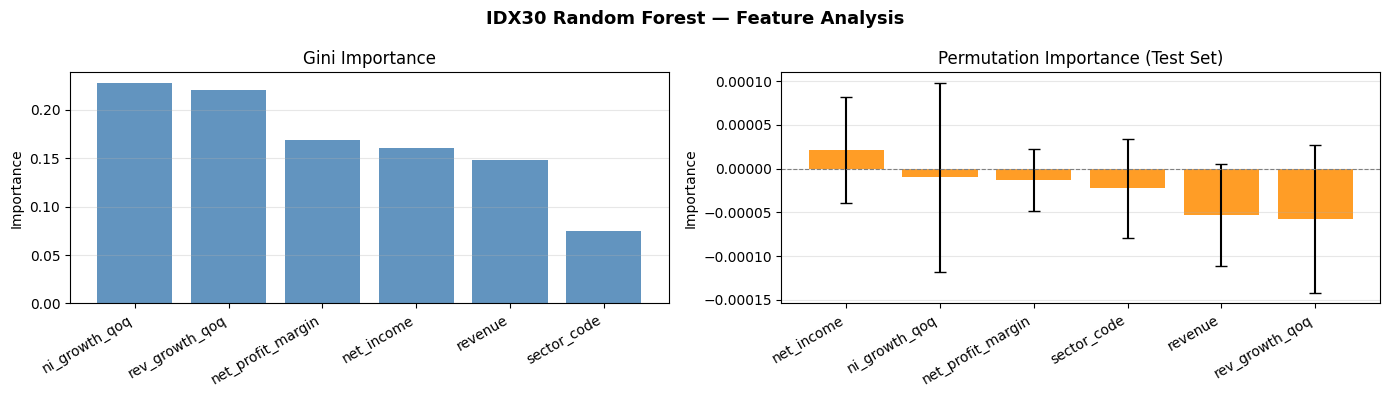

[Saved] rf_idx30_importance.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('IDX30 Random Forest — Feature Analysis', fontsize=13, fontweight='bold')

# Gini importance
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
axes[0].bar(range(len(FEATURE_COLS)), importances[order], color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(FEATURE_COLS)))
axes[0].set_xticklabels([FEATURE_COLS[i] for i in order], rotation=30, ha='right')
axes[0].set_title('Gini Importance')
axes[0].set_ylabel('Importance')
axes[0].grid(True, alpha=0.3, axis='y')

# Permutation importance
perm  = permutation_importance(rf, X_test, y_test, n_repeats=30,
                                random_state=RANDOM_STATE,
                                scoring='neg_mean_absolute_error')
order_p = np.argsort(perm.importances_mean)[::-1]
axes[1].bar(range(len(FEATURE_COLS)), perm.importances_mean[order_p],
            yerr=perm.importances_std[order_p],
            color='darkorange', alpha=0.85, capsize=4)
axes[1].set_xticks(range(len(FEATURE_COLS)))
axes[1].set_xticklabels([FEATURE_COLS[i] for i in order_p], rotation=30, ha='right')
axes[1].set_title('Permutation Importance (Test Set)')
axes[1].set_ylabel('Importance')
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rf_idx30_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] rf_idx30_importance.png')


In [9]:
# Refit on ALL data for maximum signal coverage
rf_full = RandomForestRegressor(**search.best_params_, random_state=RANDOM_STATE)
rf_full.fit(df_model[FEATURE_COLS].values, df_model[TARGET_COL].values)

# Extract BBCA rows and generate signal
df_bbca = df_model[df_model['ticker'] == TARGET_TICKER].copy().reset_index(drop=True)
df_bbca['rf_signal'] = rf_full.predict(df_bbca[FEATURE_COLS].values)

df_out = df_bbca[['ds', 'quarter_label', 'ticker', 'target_return', 'rf_signal']].copy()
df_out.to_csv(RF_PREDICTIONS_OUT, index=False)
joblib.dump(rf_full, RF_MODEL_OUT)

print(f'[Saved] {RF_PREDICTIONS_OUT}')
print(f'[Saved] {RF_MODEL_OUT}')
print(df_out.to_string(index=False))


[Saved] rf_idx30_predictions.csv
[Saved] rf_idx30_model.pkl
        ds quarter_label ticker  target_return  rf_signal
2020-03-31       2020-Q1   BBCA       0.000818   0.000984
2020-06-30       2020-Q2   BBCA      -0.000798  -0.000593
2020-09-30       2020-Q3   BBCA       0.003610   0.002822
2020-12-31       2020-Q4   BBCA      -0.001402  -0.000291
2021-03-31       2021-Q1   BBCA      -0.000290   0.000602
2021-06-30       2021-Q2   BBCA       0.002381   0.002077
2021-09-30       2021-Q3   BBCA       0.000708   0.001055
2021-12-31       2021-Q4   BBCA       0.001699   0.000863
